## Image Filtering

Applying various filters is an extremely handy technique for image analysis and manipulation. But the question is what exactly are these "filters"? An image filter or a kernel is nothing but another matrix or array of a definite structure and when applying certain mathematical operators along with these filters, it can yield certain meaningful output images which is important for image analysis.

In this notebook, we look at some of the popular image filters which is widely used.

What we will cover in this notebook:
- Average Filtering
- Gaussian Filtering
- Median Filtering
- Denoising Filtering
- Sobel Filtering
- Laplacian Filtering
- Canny Filtering

### Setup and Libraries

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Let us use `open-cv` library to load a sample image 

In [2]:
image_path = 'data/car.png'
image = cv2.imread(image_path)

(137, 368, 3)


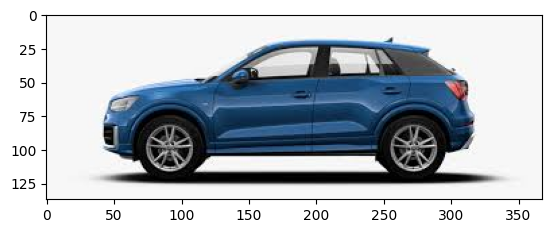

In [3]:
# Utility function to display images
def show_image(img, fig_size = None):
    print(img.shape)
    img = img.astype('uint8')

    if fig_size is not None:
        plt.figure(figsize=fig_size)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.show()

show_image(image)

### Average Filtering
Average filtering is used for blurring images in an uniform way.

Let us define a 2D filter of shape 5x5 and the filter values will be uniformly distributed since it is an average filter, which essentially means, value at each position will be same. In-order to create a normalised box filter, we will take value at each position to be 1/25.

(137, 736, 3)


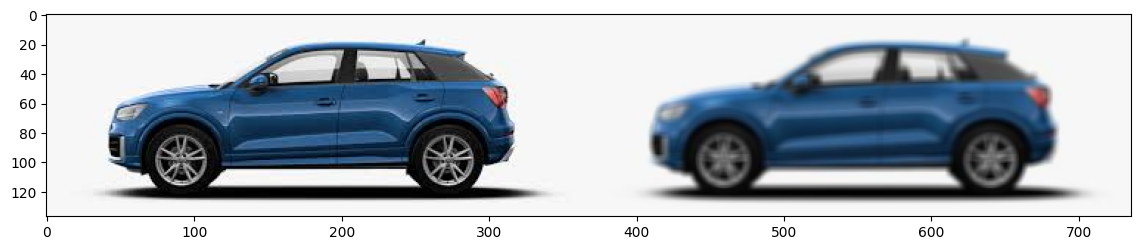

In [ ]:
kernel = np.ones((5,5))/25.

filtered_img = cv2.filter2D(image,-1,kernel)

# concatenate both the images horizontally
clubbed_image = np.concatenate((image, filtered_img), axis=1)
show_image(clubbed_image, (14,7))

Using this approach, we can blur the image in an uniform approach.

### Gaussian Filtering
Gaussian filtering is done using a Gaussian function rather than a box function. The kernel dimensions should be positive and odd. And it is often called as a Gaussian Blur filter. Instead of an uniform blurring, the blurring follows a normal distribution.

(137, 736, 3)


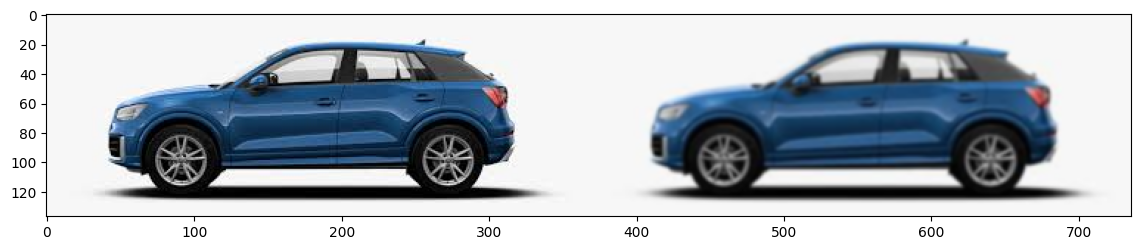

In [5]:
filtered_img = cv2.GaussianBlur(image,(5,5),0)

# concatenate both the images horizontally
clubbed_image = np.concatenate((image, filtered_img), axis=1)
show_image(clubbed_image, (14,7))

There is a very subtle difference in the blurred image created by this approach compared to uniform blurring (average filtering)

### Median Filtering
Median filters computes the median of all the pixels under the window region of the filter and the central pixel is replaced with this median value. We will see the use of these filters when we deal with removing *salt and pepper noise* and this a commonly used denoising filter.

(137, 736, 3)


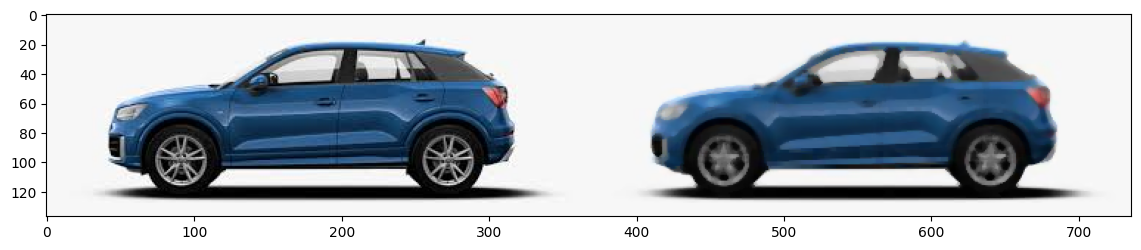

In [6]:
filtered_img = cv2.medianBlur(image, 5)

# concatenate both the images horizontally
clubbed_image = np.concatenate((image, filtered_img), axis=1)
show_image(clubbed_image, (14,7))

### Bilateral Filters
Most of the filters above (depending upon the dimensions selected) tends to blur the edges. In such a case, bilateral filters are extremely effective as it tends to preserve the edges and remove the noise. Even this filter uses a Gaussian filter in space domain, but along with that, it also uses another multiplicative Gaussian filter, which is a function of pixel intensity differences.

(137, 736, 3)


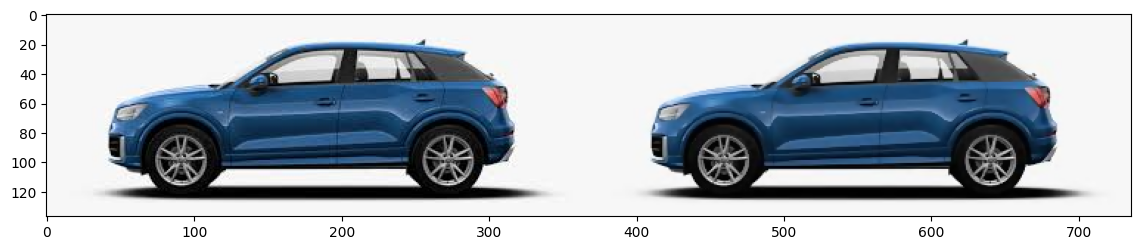

In [7]:
filtered_img = cv2.bilateralFilter(image,5,50,50)

# concatenate both the images horizontally
clubbed_image = np.concatenate((image, filtered_img), axis=1)
show_image(clubbed_image, (14,7))

### Denoising Filters
We will use median filtering approach to denoise *salt and pepper* noise. To understand this, let us take a new sample image.

(469, 500)


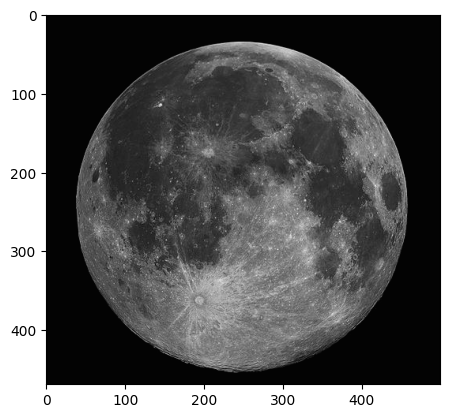

In [8]:
image_wo_noise = cv2.imread('data/moon.png',0)
show_image(image_wo_noise)

Let us now add some salt and pepper noise to it using a custom `imnoise()` that we will develop.

In [9]:
# Add noise to the image
def imnoise(img_in, dens, method = 'salt & pepper'):
    # dens is the density of noisy pixels
    if method == 'salt & pepper':
        img_out = np.copy(img_in)
        r, c = img_in.shape
        x = np.random.rand(r, c)
        ids = x < dens / 2.
        img_out[ids] = 0
        ids = dens / 2. <= x
        ids &= x < dens
        img_out[ids] = 255

        return img_out

(469, 500)


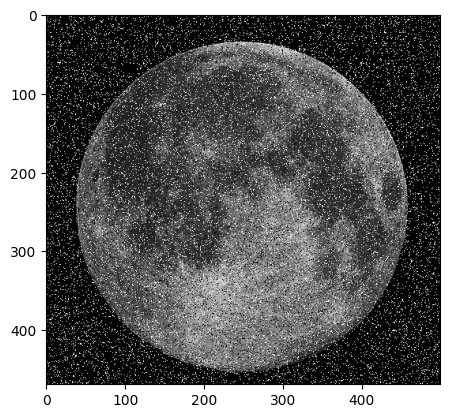

In [11]:
# Add salt & pepper
noisy_img = imnoise(image_wo_noise, 0.15)
show_image(noisy_img)

Now, let us add median blur filtering to denoise this image.

(469, 500)


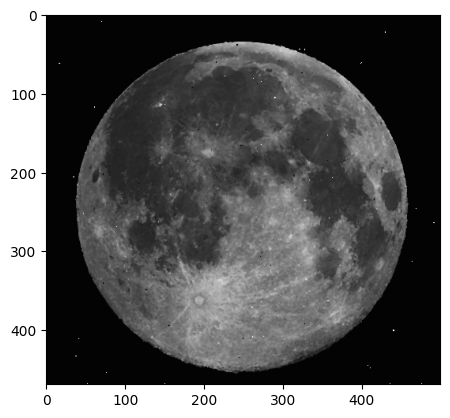

In [12]:
# Apply a median filter
median_filtered = cv2.medianBlur(noisy_img, 3)
show_image(median_filtered)

### Edge Detection
Edge detection is one of the initial problems that was solved quite efficiently in the computer vision domain. For describing an object of interest, edges are the primary features that are described first.

**What are edges?**

Visually edges are interpreted as sharp contrasts between two regions. Mathematically, contrast, or change, in a function is modeled by its derivative. So, all edge detection operators compute the gradient of the pixel values.

In this section, we will experience three different and popular edge detection filters:
- Sobel Filter
- Laplacian Filter
- Canny Filter

Let us use a new geometrical shape to understand the difference of different edge detection filters.

(256, 256)


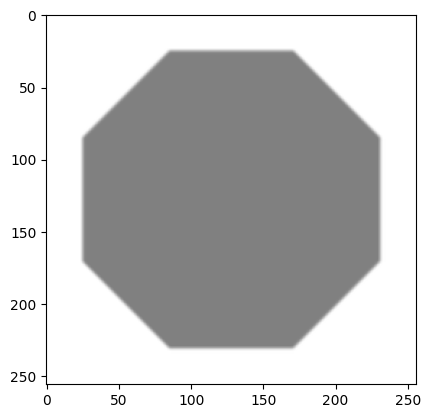

In [14]:
image = cv2.imread('data/octagon.png',0)
show_image(image)

Let us first blur this image. Blurring improves the detection of edges by removing sharp pixels (i.e., pixels with high abrupt intensity values). Otherwise, the edges will not be continuous lines.

(256, 256)


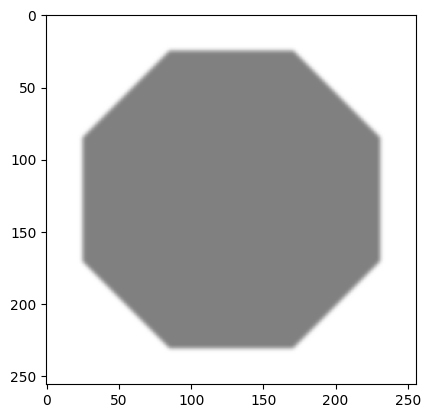

In [15]:
# remove noise
blurred = cv2.GaussianBlur(image,(5,5),0)

# Q: Why did we blur?
show_image(blurred)

### Sobel Filtering

The Sobel filter is a key edge detection operator in image processing that uses two 3x3 convolution kernels to find areas of rapid intensity change, highlighting edges by calculating approximate horizontal (G(x)) and vertical (G(y)) gradients. It's computationally efficient, relatively simple, and provides directional sensitivity, making it great for finding object boundaries in grayscale images by detecting strong brightness shifts.

(256, 256)


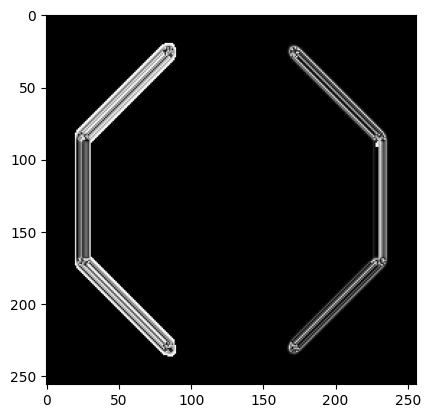

(256, 256)


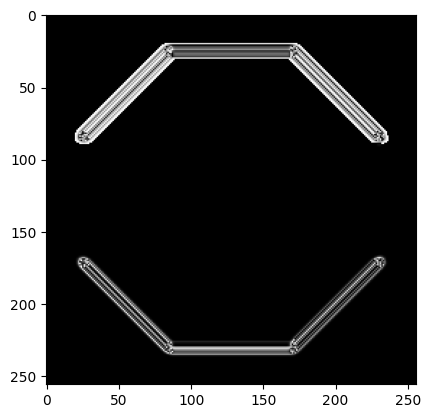

(256, 256)


C:\Users\TusharSharma\AppData\Local\Temp\ipykernel_5344\2878134377.py:4: RuntimeWarning: invalid value encountered in cast
  img = img.astype('uint8')


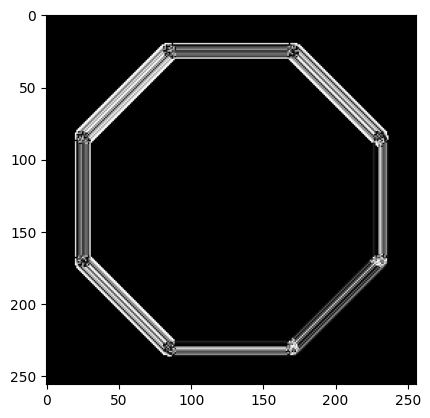

In [28]:
# Sobel Filters
sobelx = cv2.Sobel(blurred,cv2.CV_64F,1,0,ksize=5)  # x - vertical edges
show_image(sobelx)

sobely = cv2.Sobel(blurred,cv2.CV_64F,0,1,ksize=5)  # y - horizontal edge
show_image(sobely)

show_image(cv2.bitwise_or(sobelx, sobely))

These results look a little strange. It might be due to negative values (edges in opposite directions etc. calculated by `cv2.CV_64F`) or values greater than 255. Let's try taking the absolute values.

(256, 256)


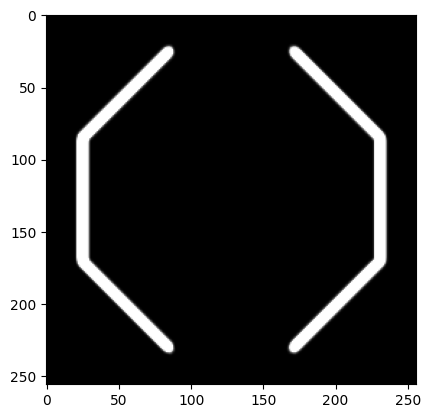

(256, 256)


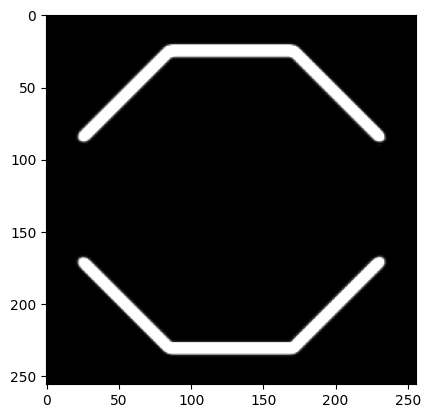

(256, 256)


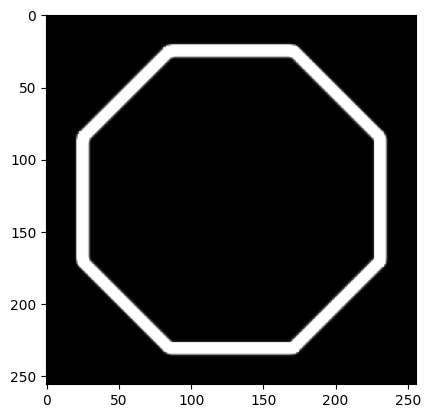

In [29]:
sobelx_abs = cv2.convertScaleAbs(sobelx)
sobely_abs = cv2.convertScaleAbs(sobely)

show_image(sobelx_abs)
show_image(sobely_abs)

show_image(cv2.bitwise_or(sobelx_abs, sobely_abs))

### Laplacian Filtering

A Laplacian filter is a high-pass spatial filter in image processing that uses the second derivative of image intensity function (intensity of pixel at $(x,y)$) to find edges and fine details, highlighting areas of rapid intensity change (like edges) while detecting them in any direction. It works by applying a convolution kernel (mask) that approximates the Laplacian operator, often resulting in an edge map that can sharpen images, though it's sensitive to noise, leading to the common use of a combined Gaussian-Laplacian filter (LoG) to smooth noise first.


(256, 256)


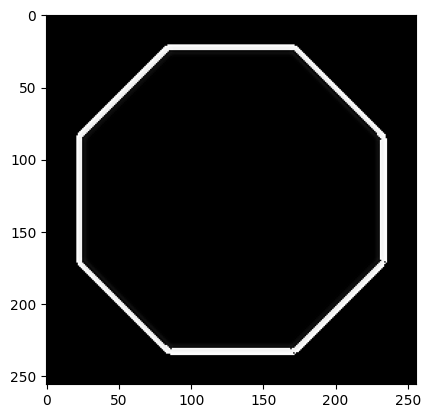

In [25]:
# Laplacian Filter
laplacian = cv2.Laplacian(blurred,cv2.CV_64F)
show_image(laplacian)

### Canny Filtering
The Canny filter (or Canny edge detector) is a popular, multi-stage algorithm in image processing for finding edges, known for its accuracy and efficiency, involving noise reduction (Gaussian blur), gradient calculation (Sobel operator), non-maximum suppression to thin edges, and hysteresis thresholding (double thresholding) to connect strong edge segments, resulting in clean, continuous edge lines for computer vision tasks like object recognition.

(256, 256)


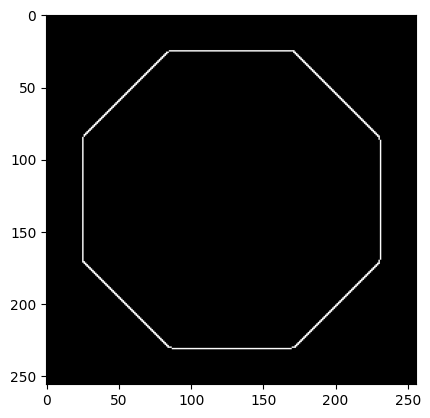

In [26]:
# Canny Filter
canny = cv2.Canny(blurred,60,20)
show_image(canny)

In this notebook, we have explored popular image filtering for blurring, denoising and detecting edges from images. Image filtering is an essential step in computer vision for more complex image processing tasks.